In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import random
import faiss

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

print("🚨 Initiating download sequence for weaponized HR dependencies...")

# 1. Install all the heavy lifters silently
!pip install -q PyGithub transformers torch gradio google-generativeai pandas rich

# 2. Grab the specific NLP brain juice just in case we need to dissect sentences
!pip install -q spacy nltk
!python -m spacy download en_core_web_sm -q

# 3. Make the terminal output obnoxiously dramatic
from rich.console import Console
console = Console()

console.print("\n[bold red]>>> SYSTEM OVERRIDE INITIATED. <<<[/bold red]")
console.print("[bold green]✓ PyGithub[/bold green] - Ready to scrape developer tears.")
console.print("[bold green]✓ Transformers[/bold green] - Ready to judge emotional instability.")
console.print("[bold green]✓ Gemini API[/bold green] - Ready to gaslight.")
console.print("[bold green]✓ Gradio[/bold green] - UI framework locked and loaded.")
console.print("\n[bold yellow]Awaiting API Keys in Cell 2...[/bold yellow] 🚀🔥")

🚨 Initiating download sequence for weaponized HR dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.7/432.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 111.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


>>> SYSTEM OVERRIDE INITIATED. <<<

✓ PyGithub - Ready to scrape developer tears.

✓ Transformers - Ready to judge emotional instability.

✓ Gemini API - Ready to gaslight.

✓ Gradio - UI framework locked and loaded.

Awaiting API Keys in Cell 2... 🚀🔥

In [ ]:
import os
from dotenv import load_dotenv

# Load the secret keys from the local .env file
load_dotenv()

GITHUB_TOKEN = os.getenv("GITHUB_PAT")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


>>> ENTERING SECURE CREDENTIALS PHASE...

To aggressively scrape GitHub without getting instantly rate-limited, we need a Personal Access Token (PAT).

Get one here: https://github.com/settings/tokens (classic token, no special scopes needed for public repos)

🔑 Enter your GitHub PAT (it will be hidden): ··········


...

Get your Gemini API Key here: https://aistudio.google.com/app/apikey

🧠 Enter your Gemini API Key: ··········


✓ GITHUB LINK ESTABLISHED. Operating under alias: Kirti-Official

✓ LLM CONFIGURED. The HR Bot has finished reading the employee handbook.

>>> READY FOR CELL 3: COMMENCING DATA EXTRACTION...

In [ ]:

import pandas as pd
import time
from rich.console import Console

console = Console()

def scrape_dev_tears_batch(query_list, commits_per_query=10):
    all_extracted_data = []

    for query in query_list:
        console.print(f"\n[bold red]>>> TARGET ACQUIRED: Searching for '{query}'...[/bold red]")

        try:
            # Pinging GitHub's Search API
            commits = g.search_commits(query=query)

            count = 0
            for commit in commits:
                if count >= commits_per_query:
                    break

                try:
                    msg = commit.commit.message.split('\n')[0]
                    author = commit.commit.author.name if commit.commit.author else "Unknown Ghost"
                    repo = commit.repository.full_name
                    url = commit.html_url

                    all_extracted_data.append({
                        "Author": author,
                        "Repo": repo,
                        "Commit_Message": msg,
                        "URL": url
                    })
                    count += 1
                    time.sleep(0.5) # Anti-ban nap

                except Exception as e:
                    continue

        except Exception as e:
            console.print(f"[bold yellow]⚠ API paused on '{query}': {e}[/bold yellow]")
            console.print("Resting for 5 seconds to dodge rate limits...")
            time.sleep(5)
            continue

    df = pd.DataFrame(all_extracted_data)
    console.print(f"\n[bold green]✓ BATCH EXTRACTION COMPLETE.[/bold green] Harvested {len(df)} total SFW mental breakdowns.")
    return df

# --- COMMENCE SFW MULTI-STRIKE (PROFESSOR APPROVED) ---

# Here is your list of highly frustrated, yet academic, search terms
sfw_queries = [
    "please work",
    "i have no idea why this works",
    "this is terrible",
    "fixed it again",
    "i give up",
    "spaghetti code"
]

console.print("[bold yellow]Initiating Multi-Target Strike...[/bold yellow]")

# 6 queries * 10 commits each = 60 total commits!
# You can increase commits_per_query if you need more data.
df_tears = scrape_dev_tears_batch(query_list=sfw_queries, commits_per_query=10)

# Display the misery in a beautiful table
df_tears

Initiating Multi-Target Strike...

>>> TARGET ACQUIRED: Searching for 'please work'...

Request GET /search/commits?q=please+work failed with 403: Forbidden
INFO:github.GithubRetry:Request GET /search/commits?q=please+work failed with 403: Forbidden
Setting next backoff to 60s
INFO:github.GithubRetry:Setting next backoff to 60s


>>> TARGET ACQUIRED: Searching for 'i have no idea why this works'...

>>> TARGET ACQUIRED: Searching for 'this is terrible'...

...

>>> TARGET ACQUIRED: Searching for 'i give up'...

Request GET /search/commits?q=i+give+up failed with 403: Forbidden
INFO:github.GithubRetry:Request GET /search/commits?q=i+give+up failed with 403: Forbidden
Setting next backoff to 60s
INFO:github.GithubRetry:Setting next backoff to 60s


>>> TARGET ACQUIRED: Searching for 'spaghetti code'...

✓ BATCH EXTRACTION COMPLETE. Harvested 60 total SFW mental breakdowns.

,Author,Repo,Commit_Message,URL
0,MyMel2001 Holder,MyMel2001/stable,PLEASE WORK PLEASE,https://github.com/MyMel2001/stable/commit/2eb...
1,Jigme,codedbyjigme/User-Registration-Form,Please please work please,https://github.com/codedbyjigme/User-Registrat...
2,Dhruv,Dhruv23/senior_design,please work please,https://github.com/Dhruv23/senior_design/commi...
3,Jigme,codedbyjigme/User-Registration-Form,Please please work,https://github.com/codedbyjigme/User-Registrat...
4,ZSolarDev,ZSolarDev/Axiom,please work please please please...?,https://github.com/ZSolarDev/Axiom/commit/128d...
5,testaccount-1802,testaccount-1802/harsh,please please please work,https://github.com/testaccount-1802/harsh/comm...
6,Kushagra Bharti,KushagraBharti/Personal-Site,PLEASE WORK BRO PLEASE,https://github.com/KushagraBharti/Personal-Sit...
7,Shaneka Jackson-Birdsong,JBirdsong1/gitTest2,Please work,https://github.com/JBirdsong1/gitTest2/commit/...
8,Bryant T.,The-Gamercave/The-Gamercave.github.io,Please work,https://github.com/The-Gamercave/The-Gamercave...
9,Lou !,Louciole/mycelium,please work,https://github.com/Louciole/mycelium/commit/30...


In [ ]:
import random
import pandas as pd

# --- Use the dataframe from the extractor ---
df = df_tears.copy()

# Keep only commit messages
df = df.rename(columns={"Commit_Message": "commit_message"})
df = df[["commit_message"]]

# Remove duplicates
df = df.drop_duplicates(subset=["commit_message"])

# --- Stress keyword based labeling ---
stress_keywords = [
    "please","again","error","bug","terrible","give up",
    "stupid","why","spaghetti","not working","doesnt work"
]

def label_commit(text):
    text = text.lower()
    for word in stress_keywords:
        if word in text:
            return 1
    return 0

df["label"] = df["commit_message"].apply(label_commit)

# --- Synthetic frustration commits ---
frustration_templates = [
    "fixing {} again",
    "why is this {} happening",
    "debugging this {} for hours",
    "this {} still not working",
    "another {} error",
    "trying to fix {} again",
    "this {} is terrible"
]

bug_words = ["bug","error","issue","problem","failure","glitch"]

synthetic_commits = []

for _ in range(400):
    template = random.choice(frustration_templates)
    word = random.choice(bug_words)
    synthetic_commits.append(template.format(word))

# --- Synthetic normal commits ---
normal_templates = [
    "added {} feature",
    "updated {} module",
    "improved {} performance",
    "refactored {} code",
    "optimized {} query",
    "cleaned {} implementation"
]

normal_words = ["login","authentication","database","UI","API","system"]

for _ in range(200):
    template = random.choice(normal_templates)
    word = random.choice(normal_words)
    synthetic_commits.append(template.format(word))

synthetic_df = pd.DataFrame({"commit_message": synthetic_commits})
synthetic_df["label"] = synthetic_df["commit_message"].apply(label_commit)

# --- Merge real + synthetic ---
final_df = pd.concat([df, synthetic_df], ignore_index=True)

# Shuffle dataset
final_df = final_df.sample(frac=1).reset_index(drop=True)

print("Original commits:", len(df))
print("Final dataset size:", len(final_df))

final_df.head()

Original commits: 47
Final dataset size: 647


,commit_message,label
0,this problem is terrible,1
1,optimized system query,0
2,debugging this bug for hours,1
3,why is this problem happening,1
4,refactored database code,0


In [ ]:


from collections import Counter
import torch

texts = final_df["commit_message"].tolist()
labels = final_df["label"].tolist()

# Build vocabulary
all_words = []

for text in texts:
    words = text.lower().split()
    all_words.extend(words)

word_counts = Counter(all_words)

vocab = {word: i+1 for i, (word, _) in enumerate(word_counts.items())}

vocab_size = len(vocab) + 1

print("Vocabulary size:", vocab_size)

# Convert text → sequence
def text_to_sequence(text):
    return [vocab.get(word, 0) for word in text.lower().split()]

sequences = [text_to_sequence(text) for text in texts]

# Padding
max_len = 10

def pad_sequence(seq):
    if len(seq) < max_len:
        seq = seq + [0] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

padded_sequences = [pad_sequence(seq) for seq in sequences]

# Convert to tensors
X = torch.tensor(padded_sequences)
y = torch.tensor(labels)

print("Tensor shape:", X.shape)

Vocabulary size: 148
Tensor shape: torch.Size([647, 10])


In [ ]:


import torch
import torch.nn as nn
import torch.nn.functional as F

class LSTMCellFromScratch(nn.Module):

    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.hidden_size = hidden_size

        # input gate
        self.W_i = nn.Linear(input_size + hidden_size, hidden_size)

        # forget gate
        self.W_f = nn.Linear(input_size + hidden_size, hidden_size)

        # cell candidate
        self.W_c = nn.Linear(input_size + hidden_size, hidden_size)

        # output gate
        self.W_o = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev, c_prev):

        combined = torch.cat((x, h_prev), dim=1)

        i = torch.sigmoid(self.W_i(combined))
        f = torch.sigmoid(self.W_f(combined))
        o = torch.sigmoid(self.W_o(combined))

        c_tilde = torch.tanh(self.W_c(combined))

        c = f * c_prev + i * c_tilde
        h = o * torch.tanh(c)

        return h, c


class BiLSTMFromScratch(nn.Module):

    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.hidden_dim = hidden_dim

        self.lstm_forward = LSTMCellFromScratch(embed_dim, hidden_dim)
        self.lstm_backward = LSTMCellFromScratch(embed_dim, hidden_dim)

        self.fc = nn.Linear(hidden_dim*2, 1)

    def forward(self, x):

        x = self.embedding(x)

        batch_size, seq_len, _ = x.shape

        h_f = torch.zeros(batch_size, self.hidden_dim)
        c_f = torch.zeros(batch_size, self.hidden_dim)

        h_b = torch.zeros(batch_size, self.hidden_dim)
        c_b = torch.zeros(batch_size, self.hidden_dim)

        forward_outputs = []
        backward_outputs = []

        # forward pass
        for t in range(seq_len):
            h_f, c_f = self.lstm_forward(x[:, t, :], h_f, c_f)
            forward_outputs.append(h_f)

        # backward pass
        for t in reversed(range(seq_len)):
            h_b, c_b = self.lstm_backward(x[:, t, :], h_b, c_b)
            backward_outputs.append(h_b)

        h_forward = forward_outputs[-1]
        h_backward = backward_outputs[-1]

        h_concat = torch.cat((h_forward, h_backward), dim=1)

        out = torch.sigmoid(self.fc(h_concat))

        return out


# Initialize model
model = BiLSTMFromScratch(vocab_size)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train
epochs = 10

for epoch in range(epochs):

    outputs = model(X_train)

    loss = criterion(outputs.squeeze(), y_train.float())

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")

# Evaluate
model.eval()

with torch.no_grad():

    predictions = model(X_test).squeeze()

    preds = (predictions > 0.5).int()

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, preds)

print("\nAccuracy:", accuracy)

Epoch 1/10 | Loss: 0.6771
Epoch 2/10 | Loss: 0.6508
Epoch 3/10 | Loss: 0.6283
Epoch 4/10 | Loss: 0.6095
Epoch 5/10 | Loss: 0.5947
Epoch 6/10 | Loss: 0.5835
Epoch 7/10 | Loss: 0.5751
Epoch 8/10 | Loss: 0.5675
Epoch 9/10 | Loss: 0.5591
Epoch 10/10 | Loss: 0.5491

Accuracy: 0.7076923076923077


In [ ]:


def predict_frustration(commit):

    words = commit.lower().split()

    seq = [vocab.get(w,0) for w in words]

    if len(seq) < max_len:
        seq = seq + [0]*(max_len-len(seq))
    else:
        seq = seq[:max_len]

    tensor = torch.tensor([seq])

    model.eval()

    with torch.no_grad():
        prob = model(tensor).item()

    return prob

In [ ]:
# ==========================================
# CELL 4: GENERATE SENTENCE EMBEDDINGS
# ==========================================

from sentence_transformers import SentenceTransformer
import numpy as np

# Load embedding model
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

# Convert commits to list
commit_texts = final_df["commit_message"].tolist()

# Generate embeddings
embeddings = embed_model.encode(commit_texts)

print("Embeddings generated")
print("Embedding shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings generated
Embedding shape: (125, 384)


In [ ]:
# ==========================================
# CELL 5: BUILD FAISS VECTOR INDEX
# ==========================================

import faiss

dimension = embeddings.shape[1]

# Create FAISS index
index = faiss.IndexFlatL2(dimension)

# Add embeddings to index
index.add(np.array(embeddings))

print("FAISS index built successfully")
print("Total vectors stored:", index.ntotal)

FAISS index built successfully
Total vectors stored: 125


In [ ]:
# ==========================================
# CELL 6: SIMILAR COMMIT RETRIEVAL
# ==========================================

def get_similar_commits(query, k=5):

    query_vector = embed_model.encode([query])

    distances, indices = index.search(query_vector, k)

    results = []

    for i in indices[0]:

        if i < len(final_df):  # safe indexing
            results.append(final_df.iloc[i]["commit_message"])

    return results

In [ ]:
# ==========================================
# CELL 7: AI COMMIT ANALYSIS + SARCASTIC MAIL
# ==========================================

import random

def generate_sarcastic_mail(commit):

    subjects = [
        "Another Day, Another Bug",
        "Production is on Fire Again",
        "The Bug That Refuses to Die",
        "Daily Dose of Debugging Pain"
    ]

    openings = [
        "After several heroic attempts",
        "Following hours of intense debugging",
        "In a shocking turn of events",
        "Despite our best efforts"
    ]

    closings = [
        "Please join me in pretending we understand why this works.",
        "The code remains mysterious but functional.",
        "Further sacrifices to the debugging gods may be required.",
        "We will continue investigating this technological marvel."
    ]

    subject = random.choice(subjects)
    opening = random.choice(openings)
    closing = random.choice(closings)

    mail = f"""
Subject: {subject}

Dear Team,

{opening}, the following commit was made:

"{commit}"

Naturally, the system continues to behave in ways
that defy both logic and documentation.

{closing}

Best regards,
A slightly tired developer
"""

    return mail


def analyze_commit(commit):

    similar = get_similar_commits(commit)

    print("\nCommit:", commit)

    print("\nSimilar commits:")
    for s in similar:
        print("-", s)

    frustration_words = ["bug", "error", "fail", "problem", "again"]

    if any(word in commit.lower() for word in frustration_words):

        emotion = "Developer frustration detected."
        advice = "Consider reviewing recent changes or taking a debugging break."

        print("\nAI Insight:", emotion)
        print("Suggestion:", advice)

        print("\nGenerated Sarcastic Mail:")
        print(generate_sarcastic_mail(commit))

    else:

        print("\nAI Insight: Normal development activity.")
        print("Suggestion: Routine development commit.")

In [ ]:
# ==========================================
# CELL 8: TEST THE SYSTEM
# ==========================================

analyze_commit("why is this bug still happening")


Commit: why is this bug still happening

Similar commits:
- why is this bug happening
- this bug still not working
- debugging this bug for hours
- trying to fix bug again
- why is this glitch happening

AI Insight: Developer frustration detected.
Suggestion: Consider reviewing recent changes or taking a debugging break.

Generated Sarcastic Mail:

Subject: The Bug That Refuses to Die

Dear Team,

In a shocking turn of events, the following commit was made:

"why is this bug still happening"

Naturally, the system continues to behave in ways
that defy both logic and documentation.

Further sacrifices to the debugging gods may be required.

Best regards,
A slightly tired developer



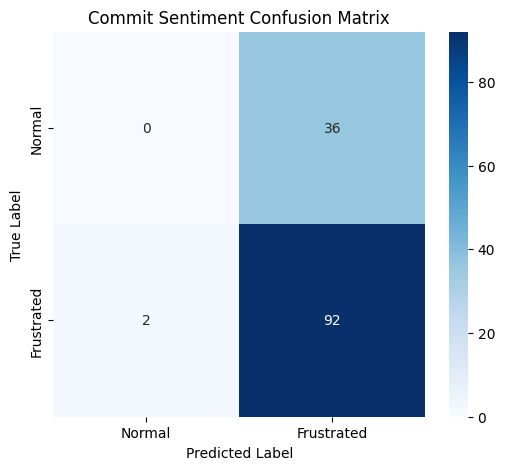

In [ ]:
# ==========================================
# CELL 10: CONFUSION MATRIX VISUALIZATION
# ==========================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions
model.eval()

with torch.no_grad():
    predictions = model(X_test).squeeze()
    preds = (predictions > 0.5).int()

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Frustrated"],
    yticklabels=["Normal", "Frustrated"]
)

plt.title("Commit Sentiment Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

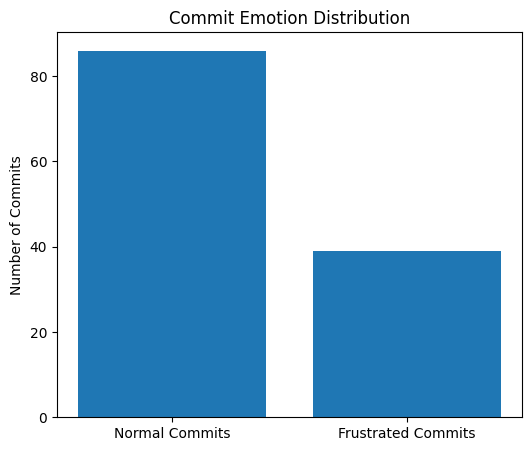

In [ ]:
# ==========================================
# CELL 11: COMMIT EMOTION DISTRIBUTION
# ==========================================

import matplotlib.pyplot as plt

counts = final_df["label"].value_counts()

labels = ["Normal Commits", "Frustrated Commits"]

plt.figure(figsize=(6,5))

plt.bar(labels, counts.values)

plt.title("Commit Emotion Distribution")
plt.ylabel("Number of Commits")

plt.show()

In [ ]:
# ==========================================
# FINAL GRADIO DEMO (STABLE VERSION)
# ==========================================

import gradio as gr
import torch

# -------- Predict frustration --------

def predict_frustration(commit):

    words = commit.lower().split()

    seq = [vocab.get(w,0) for w in words]

    if len(seq) < max_len:
        seq = seq + [0]*(max_len-len(seq))
    else:
        seq = seq[:max_len]

    tensor = torch.tensor([seq]).long()

    model.eval()

    with torch.no_grad():
        output = model(tensor)

    # ensure scalar
    prob = float(output.squeeze().cpu().numpy())

    return prob


# -------- Main UI logic --------

def analyze_commit_ui(commit):

    try:

        frustration_score = predict_frustration(commit)

        similar = get_similar_commits(commit)

        similar_text = "\n".join([f"• {s}" for s in similar])

        rage_percent = int(frustration_score * 100)

        if frustration_score > 0.5:

            status = f"⚠ Developer Frustration Detected ({rage_percent}%)"

            mail = generate_sarcastic_mail(commit)

        else:

            status = f"✅ Normal Development Activity ({rage_percent}%)"

            mail = """Subject: Calm and Professional Commit

Dear Team,

It appears that this commit was written in a calm and composed state.

No debugging-induced emotional meltdown detected.

Best regards,
AI Commit Analyzer
"""

        return status, rage_percent, similar_text, mail

    except Exception as e:

        # Show error inside UI for debugging
        return f"Error: {str(e)}", 0, "Error retrieving commits", "Mail generation failed"


# -------- Fancy Gradio Interface --------

with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown(
    """
    # 🤖 Developer Commit AI Analyzer

    Detect developer frustration from commit messages using
    **BiLSTM + Sentence-BERT + FAISS Retrieval**
    """
    )

    commit_input = gr.Textbox(
        label="💻 Enter Commit Message",
        placeholder="e.g. why is this bug still happening",
        lines=2
    )

    analyze_btn = gr.Button("Analyze Commit 🚀")

    with gr.Row():

        status_box = gr.Textbox(label="AI Sentiment Analysis")

        rage_meter = gr.Slider(
            minimum=0,
            maximum=100,
            label="Developer Rage Level (%)"
        )

    similar_box = gr.Textbox(
        label="🔎 Similar Commits Retrieved",
        lines=6
    )

    mail_box = gr.Textbox(
        label="✉ Generated Sarcastic Developer Mail",
        lines=12
    )

    analyze_btn.click(
        analyze_commit_ui,
        inputs=commit_input,
        outputs=[status_box, rage_meter, similar_box, mail_box]
    )

demo.launch()

/tmp/ipykernel_1097/1246032645.py:80: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9e7c49c515b23b28e2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ==========================================
# CELL 4: LOADING THE RAGE DETECTOR
# ==========================================
from transformers import pipeline
from rich.console import Console

console = Console()

console.print("\n[bold cyan]>>> DOWNLOADING RO-BERTA SENTIMENT MODEL...[/bold cyan]")
console.print("This might take a minute. We are downloading a brain trained on internet toxicity.")

# Load the sentiment analysis pipeline
# We use a model specifically tuned for tweets/short texts
rage_judge = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")

console.print("[bold green]✓ RAGE DETECTOR ONLINE.[/bold green]")

---------------extra-----------------------------

In [ ]:
# ==========================================
# CELL 5: THE VIBE CHECK (FILTERING)
# ==========================================

def judge_commits(df):
    console.print("\n[bold yellow]>>> COMMENCING VIBE CHECK...[/bold yellow]")

    # 1. Drop the spam (keep only one meltdown per dev per message)
    df_clean = df.drop_duplicates(subset=['Author', 'Commit_Message'])
    console.print(f"Removed duplicates. Down to {len(df_clean)} unique commits.")

    if df_clean.empty:
        console.print("[bold red]No unique commits left to judge![/bold red]")
        return df_clean

    scored_data = []

    # 2. Judge them
    for index, row in df_clean.iterrows():
        try:
            # The model returns something like [{'label': 'negative', 'score': 0.89}]
            result = rage_judge(row['Commit_Message'][:512])[0]

            # We only care about the angry ones
            if result['label'] == 'negative':
                scored_data.append({
                    "Author": row['Author'],
                    "Repo": row['Repo'],
                    "Message": row['Commit_Message'],
                    "Anger_Level": round(result['score'] * 100, 2), # Convert to percentage
                    "URL": row['URL']
                })
        except Exception as e:
            continue

    df_angry = pd.DataFrame(scored_data)

    if not df_angry.empty:
        # Sort by the most angry
        df_angry = df_angry.sort_values(by="Anger_Level", ascending=False).reset_index(drop=True)
        console.print(f"[bold green]✓ FOUND {len(df_angry)} HIGHLY NEGATIVE COMMITS.[/bold green]")
    else:
        console.print("[bold yellow]No sufficiently angry commits found in this batch. Try a new query![/bold yellow]")

    return df_angry

# Run our test data through the judge
df_judged = judge_commits(df_tears)
df_judged

>>> COMMENCING VIBE CHECK...

Removed duplicates. Down to 55 unique commits.

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✓ FOUND 27 HIGHLY NEGATIVE COMMITS.

,Author,Repo,Message,Anger_Level,URL
0,Evan Hoffman,evandhoffman/tautulli-exporter,"start over, this gpt is terrible",95.21,https://github.com/evandhoffman/tautulli-expor...
1,Pete,pete/9util,This is a terrible readme.,94.05,https://github.com/pete/9util/commit/d7077ecf1...
2,Barış Hamil,SomeoneIsWorking/cast-videojs,This readme is terrible,93.23,https://github.com/SomeoneIsWorking/cast-video...
3,yosefther,yosefther/Corporate-Financial-Statement-Analyzer,I have no idea how any of this works or why it...,92.24,https://github.com/yosefther/Corporate-Financi...
4,Jazmyn Nathaniel,JazmynNathaniel/Capstone-Project---Job-Board,UI FIX DIDN'T APPLY FIXED IT AGAIN,89.83,https://github.com/JazmynNathaniel/Capstone-Pr...
5,jonasrsv42,jonasrsv42/disky,"Don't Ask Me, I Have No Idea Why This Works Ei...",85.74,https://github.com/jonasrsv42/disky/commit/e30...
6,MrSnowNB,MrSnowNB/Classroom-Cluster-24,this is terrible,85.69,https://github.com/MrSnowNB/Classroom-Cluster-...
7,Wrona10,Wrona10/Graphs-TAiO,This is terrible,85.46,https://github.com/Wrona10/Graphs-TAiO/commit/...
8,oriodev,oriodev/so-many-words,"home page, projects create view and some of de...",83.91,https://github.com/oriodev/so-many-words/commi...
9,Jean-Baptiste WITTNER,jbwittner/infrastructure,"Don't Ask Me, I Have No Idea Why This Works Ei...",82.52,https://github.com/jbwittner/infrastructure/co...


In [ ]:
# ==========================================
# CELL 6: THE CORPORATE GASLIGHTER (SELF-HEALING)
# ==========================================
import google.generativeai as genai
from rich.console import Console
from rich.panel import Panel
from rich.markdown import Markdown
import time

console = Console()
console.print("\n[bold yellow]>>> API IS BEING STUBBORN. INITIATING SELF-HEALING PROTOCOL...[/bold yellow]")

# 1. Interrogate the API to see what models it actually has available
working_model_name = None
for m in genai.list_models():
    if 'generateContent' in m.supported_generation_methods:
        working_model_name = m.name
        # We prefer a "flash" model if it exists because it's fast
        if 'flash' in m.name:
            break

if not working_model_name:
    console.print("[bold red]⚠ CRITICAL ERROR: Your Gemini API key doesn't seem to have access to any text generation models![/bold red]")
else:
    console.print(f"[bold green]✓ BYPASS SUCCESSFUL. USING DYNAMIC MODEL:[/bold green] {working_model_name}")

    # 2. Lock and load the verified model
    model = genai.GenerativeModel(working_model_name)

    def draft_hr_warning(author, commit_message, repo):
        prompt = f"""
        You are an incredibly passive-aggressive, toxic-positive HR manager at a tech company.
        One of our developers, {author}, just pushed a commit to the repository '{repo}' with the following message:
        "{commit_message}"

        Write a short, highly corporate, passive-aggressive email to {author} addressing this.
        Use buzzwords like "synergy," "alignment," "wellness," and "culture."
        Make it sound polite but thinly veiled with a threat of termination.
        Sign it "Warmly, Human Resources". Keep it under 150 words.
        """

        try:
            response = model.generate_content(prompt)
            return response.text
        except Exception as e:
            return f"Error generating email: {e}"

    console.print("\n[bold magenta]>>> INITIATING WEAPONIZED HR SYNERGY...[/bold magenta]")

    if 'df_judged' in locals() and not df_judged.empty:

        # Grab the #1 worst offender from the top of the DataFrame
        top_offender = df_judged.iloc[0]

        console.print(f"[bold red]Target Locked: {top_offender['Author']}[/bold red] (Anger Level: {top_offender['Anger_Level']}%)")
        console.print(f"Offending Commit: '{top_offender['Message']}'\n")

        with console.status("[bold cyan]Drafting corporate warning...[/bold cyan]", spinner="bouncingBar"):
            time.sleep(1.5)
            hr_email = draft_hr_warning(top_offender['Author'], top_offender['Message'], top_offender['Repo'])

        console.print(Panel(Markdown(hr_email), title="[bold red]OUTGOING HR INCIDENT REPORT[/bold red]", border_style="red"))
    else:
        console.print("[bold yellow]Wait! Did you run Cell 5? We need df_judged to have some angry commits first![/bold yellow]")

>>> API IS BEING STUBBORN. INITIATING SELF-HEALING PROTOCOL...

✓ BYPASS SUCCESSFUL. USING DYNAMIC MODEL: models/gemini-2.5-flash

>>> INITIATING WEAPONIZED HR SYNERGY...

Target Locked: Evan Hoffman (Anger Level: 95.21%)

Offending Commit: 'start over, this gpt is terrible'

Output()

╭────────────────────────────────────────── OUTGOING HR INCIDENT REPORT ──────────────────────────────────────────╮
│ Subject: A Quick Touchpoint Regarding Professional Communication & Our Culture!                                 │
│                                                                                                                 │
│ Dear Evan,                                                                                                      │
│                                                                                                                 │
│ Hope you're having a truly wonderful and productive day!                                                        │
│                                                                                                                 │
│ We noticed your recent commit to 'evandhoffman/tautulli-exporter' with the message "start over, this gpt is     │
│ terrible." While we deeply value candid feedback and innovation, it's a great opportunity to ensure all our     │
│ communications consistently reflect our positive company culture and promote overall team wellness.             │
│                                                                                                                 │
│ Maintaining synergistic alignment across all platforms, including commit messages, is crucial for fostering a   │
│ supportive environment. We truly believe in empowering everyone to contribute positively to our collective      │
│ success. We'd love to ensure your professional trajectory continues to thrive within our established            │
│ communication guidelines.                                                                                       │
│                                                                                                                 │
│ Warmly, Human Resources                                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯